In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from stmorlet import Morlet2D1T

## 单个波包

In [ ]:
v_A = 0.4 # Alfven speed, 400km/s
U = 0.05 # background outflow speed, 50Km/s
f_0 = 0.0035 # center frequency, 3.5mHz
delta_f = 0.0004 # 1/e fold width of intensity spectrum or frequency std
dx = 3.234 # Mm
dy = 3.234 # Mm
dt = 30 # s
Nx = 400 # pixels of x-axis
Ny = 100 # pixels of y-axis
Nt = 100 # pixels of t-axis
x_r = 800 # position of reflection
r = 0.8
A0 = 5
t_c = 0.0 # wave-packet center time at x=0, s
phi_r = 0.0 # additional phase shift introduced by reflection, rad
reflection_taper_width = 2 * dx # smooth reflection gate width, Mm

x_array = np.arange(Nx) * dx
y_array = np.arange(Ny) * dy
t_array = np.arange(Nt) * dt
X, Y, T = np.meshgrid(x_array, y_array, t_array, indexing='ij')

In [ ]:
# Observer-frame propagation speeds.  The inward speed below is a positive magnitude.
c_plus = v_A + U
c_minus = v_A - U
assert c_minus > 0, 'This reflected-wave formula requires U < v_A.'

# Incident packet: launched at x=0 with envelope center t=t_c.
q_plus = T - t_c - X / c_plus
v_plus = (
    A0
    * np.exp(-2 * (np.pi * delta_f * q_plus) ** 2)
    * np.cos(2 * np.pi * f_0 * q_plus)
)

# Reflected packet: outward leg uses c_plus; return leg uses c_minus.
# At x=x_r, q_minus equals q_plus, so phi_r is the only reflection phase jump.
q_minus = T - t_c - x_r / c_plus - (x_r - X) / c_minus
reflection_gate = 0.5 * (1.0 - np.tanh((X - x_r) / reflection_taper_width))
v_minus = (
    reflection_gate
    * r
    * A0
    * np.exp(-2 * (np.pi * delta_f * q_minus) ** 2)
    * np.cos(2 * np.pi * f_0 * q_minus + phi_r)
)

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 8))
axs[0].imshow(v_plus[:, 0, :], origin='lower', extent=[t_array.min(), t_array.max(), x_array.min(), x_array.max()])
axs[0].set_xlabel('t[s]')
axs[0].set_ylabel('x[Mm]')
axs[0].set_aspect('auto')
axs[0].set_title('outward wavepack')

axs[1].imshow(v_minus[:, 0, :], origin='lower', extent=[t_array.min(), t_array.max(), x_array.min(), x_array.max()])
axs[1].set_xlabel('t[s]')
axs[1].set_ylabel('x[Mm]')
axs[1].set_aspect('auto')
axs[1].set_title('inward wavepack')

## 多波包测试

In [3]:
v_A = 0.4 # Alfven speed, 400km/s
U = 0.05 # background outflow speed, 50Km/s
f_0 = 0.0035 # center frequency, 3.5mHz
delta_f = 0.0004 # 1/e fold width of intensity spectrum or frequency std
dx = 3.234 # Mm
dy = 3.234 # Mm
dt = 30 # s
Nx = 400 # pixels of x-axis
Ny = 100 # pixels of y-axis
Nt = 400 # pixels of t-axis
x_r1 = 800 # position of the first reflection layer
x_r2 = 600 # position of the second reflection layer
r_1 = 0.0
r_2 = 0.6
phi_r = 0.0 # additional phase shift introduced by reflection, rad
reflection_taper_width = 2 * dx # smooth reflection gate width, Mm
P_0 = 0.0176
delta_fn = 1/Nt/dt

x_array = np.arange(Nx) * dx
y_array = np.arange(Ny) * dy
t_array = np.arange(Nt) * dt
X, Y, T = np.meshgrid(x_array, y_array, t_array, indexing='ij')

In [4]:
def P_f(frequency):
    return P_0 * np.exp(-(frequency-f_0)**2/delta_f**2)

def v_disturbance(frequency, rng=None):
    """Generate one Fourier component of the incident and reflected waves.

    The two reflected components inherit the same random source phase as the
    incident component.  Their sum is returned as v_minus.
    """
    vp_plus = v_A + U
    vp_minus = v_A - U
    nyquist = 1.0 / (2.0 * dt)

    if vp_minus <= 0:
        raise ValueError('The reflected-wave formula requires U < v_A.')
    if not 0.0 < frequency < nyquist:
        raise ValueError('frequency must be between zero and the Nyquist frequency.')

    random_generator = np.random if rng is None else rng
    psi_n = random_generator.uniform(0.0, 2.0 * np.pi)
    amplitude_n = np.sqrt(2.0 * P_f(frequency) * delta_fn)

    q_plus = T - X / vp_plus
    v_plus = amplitude_n * np.cos(2.0 * np.pi * frequency * q_plus + psi_n)

    def reflected_component(x_reflection, reflection_amplitude):
        q_minus = (T - x_reflection / vp_plus - (x_reflection - X) / vp_minus)
        reflection_gate = 0.5 * (1.0 - np.tanh((X - x_reflection) / reflection_taper_width))
        return (
            reflection_gate
            * reflection_amplitude
            * amplitude_n
            * np.cos(2.0 * np.pi * frequency * q_minus + psi_n + phi_r))

    v_minus_1 = reflected_component(x_r1, r_1)
    v_minus_2 = reflected_component(x_r2, r_2)
    v_minus = v_minus_1 + v_minus_2

    return v_plus, v_minus

In [5]:
f_array = delta_fn * np.arange(1, Nt // 2)
v_plus_cube = np.zeros((Nx, Ny, Nt))
v_minus_cube = np.zeros((Nx, Ny, Nt))
for f in f_array:
    v_p, v_m = v_disturbance(f)
    v_plus_cube += v_p
    v_minus_cube += v_m

Text(0.5, 1.0, 'inward wavepack')

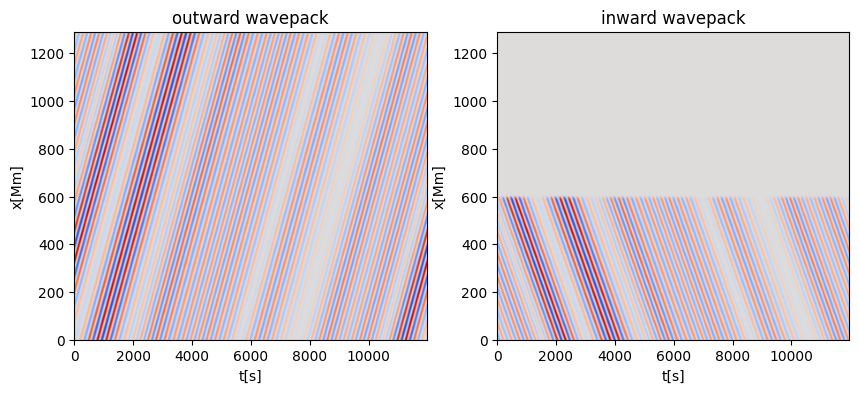

In [6]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
axs[0].imshow(v_plus_cube[:, 0, :], origin='lower', cmap='coolwarm', extent=[t_array.min(), t_array.max(), x_array.min(), x_array.max()])
axs[0].set_xlabel('t[s]')
axs[0].set_ylabel('x[Mm]')
axs[0].set_aspect('auto')
axs[0].set_title('outward wavepack')
axs[1].imshow(v_minus_cube[:, 0, :], origin='lower', cmap='coolwarm', extent=[t_array.min(), t_array.max(), x_array.min(), x_array.max()])
axs[1].set_xlabel('t[s]')
axs[1].set_ylabel('x[Mm]')
axs[1].set_aspect('auto')
axs[1].set_title('inward wavepack')

In [7]:
v_cube = v_minus_cube + v_plus_cube
morlet = Morlet2D1T(
    dx=dx,
    dy=dy,
    dt=dt,
    epsilon=1,
    k0=6,
    omega0=6.0,
    precision="single",
    backend="gpu",
    device=0,
    boundary=None,
)

In [8]:
omega_array = np.linspace(1, 10, 20)*2*np.pi*1e-3
theta_array = np.linspace(-5, 5, 5)
v_A_array = np.linspace(0.9, 1.1, 5) * v_A

x_analysis_slice = slice(100, 150)
lag_array = np.arange(18, 91, dtype=int)
theta_radian = np.deg2rad(theta_array)

# Only gamma2 is retained across different omega values.
# Axis order: (omega, x, tau).
gamma2 = np.full(
    (len(omega_array), x_analysis_slice.stop-x_analysis_slice.start, len(lag_array)),
    np.nan,
    dtype=np.float32,
)

for omega_index, omega in enumerate(omega_array):
    k_array_plus = omega/(v_A_array+U)
    k_array_minus = omega/(v_A_array-U)

    # stmorlet requires strictly increasing k axes.  Use the same ordering
    # for both branches so every k_plus[i] remains paired with k_minus[i].
    pair_order = np.argsort(k_array_plus)
    k_array_plus = k_array_plus[pair_order]
    k_array_minus = k_array_minus[pair_order]
    k_plus_ascending = k_array_plus

    w_plus_path = morlet.cwt_polar(
        v_cube,
        k_array_plus,
        theta_array,
        np.array([omega]),
        output='memmap',
        path='./data/single_omega_w_plus.npy',
        overwrite=True,
    )
    w_minus_path = morlet.cwt_polar(
        v_cube,
        k_array_minus,
        theta_array+180,
        np.array([omega]),
        output='memmap',
        path='./data/single_omega_w_minus.npy',
        overwrite=True,
    )

    # Read coefficients lazily from disk.  The same two files are overwritten
    # at the next omega after these mappings have been released.
    w_plus = np.load(w_plus_path, mmap_mode='r')
    w_minus = np.load(w_minus_path, mmap_mode='r')

    # Frequency-dependent 4*a_t temporal buffer.  Removing max(lag_array)
    # from the end makes wp identical for every lag.
    boundary_t = int(np.ceil(4.0*6.0/(omega*dt)))
    time_start = boundary_t
    time_stop = Nt - boundary_t - lag_array.max()

    if time_stop <= time_start:
        print(
            f'skip f={omega/(2*np.pi)*1e3:.3f} mHz: '
            'no common valid time interval'
        )
        del w_plus, w_minus
        continue

    # Remove the singleton omega axis.  Shape:
    # (x_analysis, y, common_time, matched_k, theta).
    wp = w_plus[
        x_analysis_slice,
        :,
        time_start:time_stop,
        :,
        :,
        0,
    ]

    # Local s_++(x,y,t) for this single omega.  np.trapz already performs
    # the theta and k integrations, so no extra integration factor is used.
    s_plus_plus_theta = np.trapz(
        np.abs(wp)**2,
        x=theta_radian,
        axis=-1,
    )
    s_plus_plus = np.trapz(
        s_plus_plus_theta,
        x=k_plus_ascending,
        axis=-1,
    )
    S_plus_plus_single = np.mean(s_plus_plus, axis=(1, 2))

    for lag_index, lag in enumerate(lag_array):
        wm = w_minus[
            x_analysis_slice,
            :,
            time_start+lag:time_stop+lag,
            :,
            :,
            0,
        ]

        # Local s_+-(x,y,t) for this single (omega, lag).
        s_plus_minus_theta = np.trapz(
            wp*np.conj(wm),
            x=theta_radian,
            axis=-1,
        )
        s_plus_minus = np.trapz(
            s_plus_minus_theta,
            x=k_plus_ascending,
            axis=-1,
        )
        S_plus_minus_single = np.mean(s_plus_minus, axis=(1, 2))

        # Local s_-- uses the same matched-k measure as s_+- and s_++.
        s_minus_minus_theta = np.trapz(
            np.abs(wm)**2,
            x=theta_radian,
            axis=-1,
        )
        s_minus_minus = np.trapz(
            s_minus_minus_theta,
            x=k_plus_ascending,
            axis=-1,
        )
        S_minus_minus_single = np.mean(s_minus_minus, axis=(1, 2))

        denominator_single = S_plus_plus_single*S_minus_minus_single
        valid_denominator = (
            np.isfinite(denominator_single)
            & (denominator_single > 0)
        )

        np.divide(
            np.abs(S_plus_minus_single)**2,
            denominator_single,
            out=gamma2[omega_index, :, lag_index],
            where=valid_denominator,
        )
        gamma2[omega_index, :, lag_index] = np.clip(
            gamma2[omega_index, :, lag_index], 0.0, 1.0
        )

        del (
            wm,
            s_plus_minus_theta,
            s_plus_minus,
            S_plus_minus_single,
            s_minus_minus_theta,
            s_minus_minus,
            S_minus_minus_single,
            denominator_single,
        )

    del (
        wp,
        s_plus_plus_theta,
        s_plus_plus,
        S_plus_plus_single,
        w_plus,
        w_minus,
    )

print('gamma2 shape (omega, x, tau):', gamma2.shape)


/tmp/ipykernel_2202261/2666249032.py:28: RuntimeWarning: Morlet wavelet effective support exceeds the input extent along axes: y
  w_plus_path = morlet.cwt_polar(


CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

/tmp/ipykernel_2202261/2666249032.py:37: RuntimeWarning: Morlet wavelet effective support exceeds the input extent along axes: y
  w_minus_path = morlet.cwt_polar(


CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

/tmp/ipykernel_2202261/2666249032.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s_plus_plus_theta = np.trapz(
/tmp/ipykernel_2202261/2666249032.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s_plus_plus = np.trapz(
/tmp/ipykernel_2202261/2666249032.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s_plus_minus_theta = np.trapz(
/tmp/ipykernel_2202261/2666249032.py:107: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s_plus_minus = np.trapz(
/tmp/ipykernel_2202261/2666249032.py:115: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integr

...

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

CWT polar:   0%|          | 0/1 [00:00<?, ?block/s]

gamma2 shape (omega, x, tau): (20, 50, 73)


In [9]:
np.save('./data/gamma2.npy', gamma2 )

In [8]:
omega_array/2/np.pi

array([0.001     , 0.00147368, 0.00194737, 0.00242105, 0.00289474,
       0.00336842, 0.00384211, 0.00431579, 0.00478947, 0.00526316,
       0.00573684, 0.00621053, 0.00668421, 0.00715789, 0.00763158,
       0.00810526, 0.00857895, 0.00905263, 0.00952632, 0.01      ])

In [10]:
gamma2 = np.load('./data/gamma2.npy')
tau_axis = lag_array * dt
x_axis = x_array[x_analysis_slice]

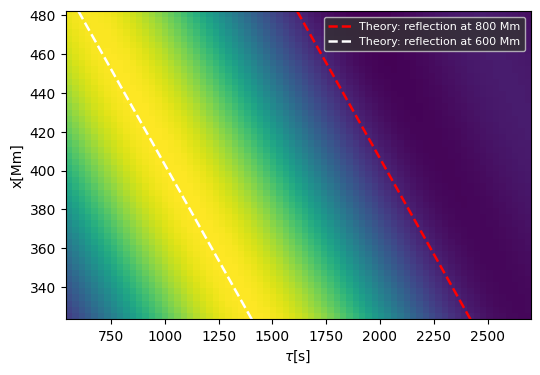

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(gamma2[5, :, :], origin='lower', extent=(tau_axis.min(), tau_axis.max(), x_axis.min(), x_axis.max()))
ax.set_aspect('auto')
ax.set_xlabel(r'$\tau$[s]')
ax.set_ylabel('x[Mm]')

# Theoretical round-trip delays; horizontal axis is tau, vertical axis is x.
delay_factor = 1.0/(v_A + U) + 1.0/(v_A - U)
tau_r1 = (x_r1 - x_axis) * delay_factor
tau_r2 = (x_r2 - x_axis) * delay_factor
ax.plot(tau_r1, x_axis, color='red', linestyle='--', linewidth=1.8,
        label=f'Theory: reflection at {x_r1:g} Mm')
ax.plot(tau_r2, x_axis, color='white', linestyle='--', linewidth=1.8,
        label=f'Theory: reflection at {x_r2:g} Mm')
ax.set_xlim(tau_axis.min(), tau_axis.max())
ax.set_ylim(x_axis.min(), x_axis.max())
ax.legend(loc='best', fontsize=8, facecolor='0.2', labelcolor='white')
plt.show()